# Modelos finales · TFM Energía UCM

Entrena **una arquitectura por familia** sobre la matriz ganadora, con varias semillas, y
las deja guardadas con todo lo que hace falta para volver a usarlas.

## Por qué no vale ninguno de los notebooks anteriores

`modelo_rnn_deeplearning`, `v2_temario` y `v3_sin_series_clasicas` entrenan 15-18 modelos,
miran el resultado en pantalla y **los tiran al terminar**. Nunca se guardó ninguno. Sirven
para el relato —aquí probamos esto, salió así— no para entregar:

| | notebooks v1/v2/v3 | este |
|---|---|---|
| semillas | una | **tres**, con media ± desviación |
| guarda el `.keras` | no | **sí** |
| guarda el preprocesado | no | **sí** |
| modelos | 15-18, muchos ya descartados | **8**, uno por familia |

Y los tres entrenan los **mismos** 15 modelos: v2 añade la escalera del temario y Hyperband,
v3 quita las series clásicas. Nada de eso cambia cuál es el mejor — la escalera se queda en
13,19 frente a los 12,28 del GRU.

## Qué es una familia

Variantes de un mismo esqueleto no son familias distintas. `Seq2Seq residuo`, `+ pesos`,
`+ fine-tuning` y las seis del temario son el mismo encoder-decoder entrenado de otra
manera. Meterlas todas en un ensemble le daba a esa familia el **62 % del voto** y al GRU
—el mejor modelo individual— un 6 %. Un ensemble promedia errores *no correlacionados*:
diez copias casi idénticas no cancelan nada.

Y ojo con los nombres, porque mezclan **dos ejes distintos**:

- **la celda** — `SimpleRNN`, `LSTM`, `GRU` — qué tipo de memoria tiene la neurona
- **la topología** — directa o encoder-decoder — cómo se cablea la red

Un seq2seq no es un tipo de LSTM: es una forma de conectar, y puede estar hecho de
LSTM o de GRU indistintamente. Como `gru` nombra una celda y `seq2seq` una topología,
la lista de abajo se lee mejor con las dos columnas separadas:

| familia | topología | celda | qué aísla frente a `seq2seq` |
|---|---|---|---|
| `seq2seq` | enc-decoder | LSTM | — es la referencia |
| `gru` | enc-decoder | GRU | **la celda** |
| `simplernn` | enc-decoder | SimpleRNN | la celda, escalón básico (~35 k par.) |
| `lstm` | **directa** | LSTM | **el decoder** |
| `seq2seq_absoluto` | enc-decoder | LSTM | **el objetivo**: precio, no residuo |
| `conv1d_lstm` | enc-decoder | LSTM | convolución con stride en la entrada |
| `denso` | vista aplanada | — | control sin recurrencia |
| `boosting` | vista aplanada | — | LightGBM, un modelo por hora |

Las tres comparaciones del centro mueven **una sola cosa** cada una respecto a la
referencia. En una primera versión `lstm` no tenía rama propia y acababa construyendo
el mismo encoder-decoder que `seq2seq` —259.681 parámetros idénticos, r = 0,99947 entre
sus predicciones— así que la ablación del decoder no existía y el ensemble le daba doble
voto a esa arquitectura. Ahora `lstm` es directa: encoder, estáticos, y una `Dense` que
saca las 24 horas de golpe.

El último entra **pese a perder en MAE**, porque es de los que mejor captura el spread. La
correlación entre MAE y captura es −0,285: son métricas casi independientes, y para operar
una batería manda la segunda. Elegir campeón solo por MAE elige mal para el capítulo 7.

## 0 · ¿Está usando la GPU?

Conviene comprobarlo **antes** de lanzar los ~40 minutos de entrenamiento. Que TensorFlow
*vea* la tarjeta no garantiza que la use: si falta una librería de CUDA, cae a CPU en
silencio y solo lo notas por lo lento que va.

Las tres comprobaciones de abajo, de menos a más concluyente:

1. **la ve** — `list_physical_devices` devuelve algo
2. **coloca operaciones en ella** — una multiplicación que informa dónde se ejecutó
3. **es más rápida que la CPU** — la única que descarta que esté cayendo a CPU sin avisar

In [1]:
import tensorflow as tf, time, numpy as np

gpus = tf.config.list_physical_devices("GPU")
print(f"1. dispositivos GPU visibles: {len(gpus)}")
for g in gpus:
    det = tf.config.experimental.get_device_details(g)
    print(f"     {g.name} · {det.get('device_name', '?')} · "
          f"compute capability {det.get('compute_capability', '?')}")

if not gpus:
    print()
    print("   NO HAY GPU. Vas a entrenar por CPU: cuenta horas en lugar de minutos.")
    print("   Si estas en VS Code, revisa que el kernel sea el de WSL y no el de Windows")
    print("   -- TensorFlow >= 2.11 no usa CUDA en Windows nativo.")
else:
    # 2. ¿coloca las operaciones ahi de verdad?
    tf.debugging.set_log_device_placement(False)
    with tf.device("/GPU:0"):
        a = tf.random.normal((2000, 2000))
        _ = tf.matmul(a, a)
    print(f"\n2. una matmul de 2000x2000 se coloco en: {a.device.split('/')[-1]}")

    # 3. la prueba que de verdad descarta que este cayendo a CPU en silencio
    def cronometrar(dispositivo, n=3):
        with tf.device(dispositivo):
            x = tf.random.normal((4000, 4000))
            tf.matmul(x, x).numpy()                 # calienta, no cuenta
            t = time.perf_counter()
            for _ in range(n):
                tf.matmul(x, x).numpy()
            return (time.perf_counter() - t) / n

    t_gpu = cronometrar("/GPU:0")
    t_cpu = cronometrar("/CPU:0")
    print(f"\n3. matmul 4000x4000:  GPU {t_gpu*1000:7.1f} ms  ·  CPU {t_cpu*1000:7.1f} ms"
          f"  ->  x{t_cpu/t_gpu:.0f}")
    if t_cpu / t_gpu < 2:
        print("   SOSPECHOSO: la GPU deberia ir bastante mas rapido que eso. Puede que")
        print("   este cayendo a CPU sin avisar.")
    else:
        print("   La GPU esta trabajando.")

    memoria = tf.config.experimental.get_memory_info("GPU:0")
    print(f"\n   memoria en uso ahora: {memoria['current']/2**20:,.0f} MB "
          f"(pico {memoria['peak']/2**20:,.0f} MB)")
    print("   Con `nvidia-smi -l 2` en otra terminal lo ves en vivo mientras entrena:")
    print("   la columna GPU-Util deberia moverse entre el 30 % y el 90 %.")

I0000 00:00:1788044377.568321 1060480 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788044377.703501 1060480 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788044379.328435 1060480 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


1. dispositivos GPU visibles: 1
     /physical_device:GPU:0 · NVIDIA GeForce RTX 5050 Laptop GPU · compute capability (12, 0)


W0000 00:00:1788044381.669864 1060480 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1788044381.675978 1060480 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788044381.975385 1060480 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1788044381.977357 1060480 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:04:00.0, compute capability: 12.0a



2. una matmul de 2000x2000 se coloco en: device:GPU:0

3. matmul 4000x4000:  GPU    27.1 ms  ·  CPU   187.2 ms  ->  x7
   La GPU esta trabajando.

   memoria en uso ahora: 31 MB (pico 214 MB)
   Con `nvidia-smi -l 2` en otra terminal lo ves en vivo mientras entrena:
   la columna GPU-Util deberia moverse entre el 30 % y el 90 %.


In [2]:
import sys, time, json
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "gold").is_dir())
sys.path.append(str(REPO / "scripts"))

MATRIZ   = "nucleo"          # la ganadora de la comparación del notebook 05
SEMILLAS = 3
FAMILIAS = ["gru", "conv1d_lstm", "seq2seq", "simplernn", "lstm", "denso",
            "boosting", "seq2seq_absoluto"]

EJECUTAR = True             # <- ponlo a True y ejecuta esta celda

SALIDA = REPO / "data" / "gold" / f"finales_{MATRIZ}"
print(f"matriz {MATRIZ} · {len(FAMILIAS)} familias x {SEMILLAS} semillas = "
      f"{len(FAMILIAS) * SEMILLAS} entrenamientos")
print(f"salida: {SALIDA}")

matriz nucleo · 8 familias x 3 semillas = 24 entrenamientos
salida: /mnt/c/Users/torgi/proyectos/tfm-energia/data/gold/finales_nucleo


## 1 · Entrenar

Cada entrenamiento escribe en `por_semilla.csv`, así que se puede parar y continuar: al
relanzar salta los que ya estén.

Con `guardar=True` cada familia deja su `.keras` **y** su `.preprocesado.json`. Lo segundo
no es opcional: un `.keras` guarda pesos, no la estandarización ni el orden de columnas.
Cargarlo sin eso devuelve números plausibles y equivocados, sin ningún aviso — el modelo
aprendió que el canal 17 es la eólica programada, y si la matriz se regenera con otro orden
sigue prediciendo tan tranquilo.

In [3]:
GUARDAR = True

if not EJECUTAR:
    print("EJECUTAR = False. Cambia a True en la celda anterior.")
    print("Si ya lo lanzaste por terminal, salta a la sección 2: lee los mismos ficheros.")
else:
    import numpy as np, pandas as pd
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from preparar_tensores import preparar, residuo
    import entrenar_finales as EF

    print("GPU:", bool(tf.config.list_physical_devices("GPU")))
    SALIDA.mkdir(parents=True, exist_ok=True)

    T = preparar(MATRIZ)
    yr, inv_r, mu_r, sd_r = residuo(T)
    mu_y, sd_y = float(T.y[T.tr].mean()), float(T.y[T.tr].std())
    ys = ((T.y - mu_y) / sd_y).astype("float32")
    inv_abs = lambda p, m: p * sd_y + mu_y

    nv = EF.metricas(T.y[T.va], T.naive[T.va])
    nt = EF.metricas(T.y[T.te], T.naive[T.te])
    print(f"   naive: val {nv['MAE']:.2f} · test {nt['MAE']:.2f} "
          f"· captura val {nv['captura_%']:.1f}%")
    print()

    csv = SALIDA / "por_semilla.csv"
    filas = pd.read_csv(csv).to_dict("records") if csv.exists() else []
    yahay = {(r["familia"], r["semilla"]) for r in filas}
    t0 = time.time()
    for fam in FAMILIAS:
        for s in range(SEMILLAS):
            if (fam, EF.SEMILLA + s) in yahay:
                continue
            pv, pt, npar, modelo = EF.entrenar(fam, T, yr, inv_r, ys, inv_abs,
                                               EF.SEMILLA + s, keras, layers)
            mv, mt = EF.metricas(T.y[T.va], pv), EF.metricas(T.y[T.te], pt)
            filas.append({"familia": fam, "semilla": EF.SEMILLA + s, "parametros": npar,
                          "MAE_val": round(mv["MAE"], 3), "MAE_test": round(mt["MAE"], 3),
                          "captura_val_%": round(mv["captura_%"], 2),
                          "captura_test_%": round(mt["captura_%"], 2),
                          "pico_1h_test_%": round(mt["pico_1h_%"], 2),
                          "vs_naive_val_%": round(100 * (mv["MAE"] / nv["MAE"] - 1), 1)})
            pd.DataFrame(filas).to_csv(csv, index=False)
            _cols = [f"h{h:02d}" for h in range(24)]
            pd.DataFrame(pv, index=pd.to_datetime(T.fechas[T.va]),
                         columns=_cols).to_csv(SALIDA / f"pred_val_{fam}__s{s}.csv")
            # Tambien las de test: sin ellas la seccion 3 no puede calcular el MAE
            # del ensemble y se quedaba en la matriz de correlaciones.
            pd.DataFrame(pt, index=pd.to_datetime(T.fechas[T.te]),
                         columns=_cols).to_csv(SALIDA / f"pred_test_{fam}__s{s}.csv")
            print(f"   {fam:18s} s{s}  MAE val {mv['MAE']:6.3f} · test {mt['MAE']:6.3f} "
                  f"· captura {mt['captura_%']:5.1f}%   [{(time.time()-t0)/60:.0f} min]")

            # TODAS las semillas, no solo la primera. El representante de cada familia
            # se elige despues por MAE de VALIDACION, y puede ser la s1 o la s2: guardar
            # solo la s0 exportaria un modelo distinto del que la tabla declara mejor.
            # Ocupan medio mega cada uno, asi que no hay razon para elegir antes de saber.
            if GUARDAR and modelo is not None:
                modelo.save(SALIDA / f"{fam}__s{s}.keras")
                pre = T.preprocesado()   # mismo para las 3 semillas
                pre["familia"] = fam
                pre["objetivo"] = "absoluto" if fam == "seq2seq_absoluto" else "residuo"
                pre["destipificar"] = ({"mu": mu_y, "sd": sd_y, "nota": "y = pred*sd + mu"}
                                       if fam == "seq2seq_absoluto"
                                       else {"mu": mu_r, "sd": sd_r,
                                             "nota": "y = pred*sd + mu + naive(dia D)"})
                pre["entrada"] = "plana" if fam in ("denso", "boosting") else "tensores"
                (SALIDA / f"{fam}.preprocesado.json").write_text(
                    json.dumps(pre, indent=2, ensure_ascii=False), encoding="utf-8")

    (SALIDA / "meta.json").write_text(json.dumps({
        "matriz": MATRIZ, "hash": T.meta.get("hash"), "semillas": SEMILLAS,
        "naive_val_MAE": round(nv["MAE"], 3), "naive_test_MAE": round(nt["MAE"], 3),
        "dias_train": int(T.tr.sum()), "dias_val": int(T.va.sum()),
        "dias_test": int(T.te.sum())}, indent=2), encoding="utf-8")
    print()
    print(f"Listo. {len(filas)} entrenamientos en {SALIDA}")

GPU: True
nucleo    hash 4a8f328e · 2,388 dias · encoder 51 canales · decoder 22 · estaticos 29 · train 1812 val 365 test 211
   naive: val 19.95 · test 16.70 · captura val 81.7%



/home/torgi/tf/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/torgi/tf/lib/python3.12/site-packages/lightgbm/basic.py:668: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/home/torgi/tf/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/torgi/tf/lib/python3.12/site-packages/lightgbm/basic.py:668: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(
/home/torgi/tf/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LG

   boosting           s2  MAE val 13.284 · test 13.942 · captura  88.4%   [5 min]

Listo. 24 entrenamientos en /mnt/c/Users/torgi/proyectos/tfm-energia/data/gold/finales_nucleo


### 1.1 · Recuperar las predicciones de test que faltan

Las ejecuciones anteriores solo guardaban `pred_val_*`. Sin las de test no hay MAE de
ensemble que calcular.

No hace falta reentrenar: los `.keras` están guardados, así que es **inferencia pura** y
tarda segundos. Solo `boosting` no tiene modelo en disco —LightGBM no se serializa aquí— y
esa familia hay que reentrenarla.

In [4]:
import numpy as np, pandas as pd
from tensorflow import keras as K
from preparar_tensores import preparar, residuo
from entrenar_finales import vista_plana

if "T" not in globals():
    T = preparar(MATRIZ)
_yr, inv_r, _, _ = residuo(T)
mu_y, sd_y = float(T.y[T.tr].mean()), float(T.y[T.tr].std())
cols = [f"h{h:02d}" for h in range(24)]
fechas_te = pd.to_datetime(T.fechas[T.te])

hechos = pd.read_csv(SALIDA / "por_semilla.csv")
recuperadas, sin_modelo = [], []
for r in hechos.itertuples():
    s = r.semilla - 42
    if (SALIDA / f"pred_test_{r.familia}__s{s}.csv").exists():
        continue
    # boosting no es un .keras sino una carpeta con 24 ficheros nativos de LightGBM
    if r.familia == "boosting":
        from entrenar_finales import BosqueHorario
        carpeta = SALIDA / f"{r.familia}__s{s}"
        if not carpeta.is_dir():
            sin_modelo.append(f"{r.familia}__s{s}")
            continue
        m = BosqueHorario.cargar(carpeta)
    else:
        mk = SALIDA / f"{r.familia}__s{s}.keras"
        if not mk.exists():
            sin_modelo.append(f"{r.familia}__s{s}")
            continue
        m = K.models.load_model(mk)
    X = vista_plana(T)[T.te] if r.familia in ("denso", "boosting") else T.ent(T.te)
    p = m.predict(X, verbose=0)
    # destipificar por el mismo camino que uso el entrenamiento
    p = (p * sd_y + mu_y) if r.familia == "seq2seq_absoluto" else inv_r(p, T.te)
    pd.DataFrame(p, index=fechas_te, columns=cols).to_csv(
        SALIDA / f"pred_test_{r.familia}__s{s}.csv")
    recuperadas.append(f"{r.familia}__s{s}")

print(f"{len(recuperadas)} predicciones de test recuperadas por inferencia")
if sin_modelo:
    print(f"sin .keras, hay que reentrenar: {sin_modelo}")

0 predicciones de test recuperadas por inferencia


## 2 · Resultados por familia

Media y desviación sobre las semillas. **La desviación es la que dice si una diferencia
significa algo**: dos ejecuciones idénticas difieren hasta 0,58 en MAE, así que por debajo
de eso no se decide nada.

In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

csv = SALIDA / "por_semilla.csv"
if not csv.exists():
    print(f"Todavía no hay resultados en {csv}.")
    print("Ejecuta la sección 1, o lánzalo por terminal:")
    print(f"   python scripts/entrenar_finales.py --matriz {MATRIZ} "
          f"--semillas {SEMILLAS} --guardar-modelos")
    f = None
else:
    f = pd.read_csv(csv)
    meta = json.loads((SALIDA / "meta.json").read_text()) if (SALIDA / "meta.json").exists() else {}
    naive_te = meta.get("naive_test_MAE", np.nan)
    res = (f.groupby("familia").agg(
        n=("semilla", "size"), parametros=("parametros", "first"),
        MAE_val=("MAE_val", "mean"), sd_val=("MAE_val", "std"),
        MAE_test=("MAE_test", "mean"), sd_test=("MAE_test", "std"),
        captura_test=("captura_test_%", "mean"),
        pico_1h=("pico_1h_test_%", "mean")).round(3).sort_values("MAE_val"))
    res["vs_naive_%"] = (100 * (res.MAE_test / naive_te - 1)).round(1)
    # Positivo = el modelo generaliza PEOR de lo que prometia en validacion. Es la
    # columna que separa a los que se ajustaron al periodo de seleccion de los que
    # aprendieron algo que aguanta en 2026.  val = 2025 entero, test = ene-jul 2026.
    res["salto"] = (res.MAE_test - res.MAE_val).round(3)
    display(res)
    peor = res.salto.idxmax()
    if res.salto.max() > 1:
        print(f"OJO: {peor} empeora {res.salto.max():+.2f} al pasar a test. "
              f"Su puesto en validación no dice nada de cómo predice 2026.")
    print(f"naive de test: {naive_te} €/MWh")
    print(f"{len(f)} de {len(FAMILIAS) * SEMILLAS} entrenamientos")

HAY = f is not None and len(f) > 0

,n,parametros,MAE_val,sd_val,MAE_test,sd_test,captura_test,pico_1h,vs_naive_%,salto
familia,,,,,,,,,,
denso,3,566040,12.786,0.205,13.997,0.824,88.987,74.723,-16.2,1.211
boosting,3,10319,13.293,0.023,13.745,0.172,88.243,77.253,-17.7,0.452
lstm,3,322712,13.398,0.257,16.722,0.605,89.243,73.303,0.1,3.324
gru,3,196129,13.585,0.189,12.857,0.083,89.203,77.097,-23.0,-0.728
seq2seq,3,259681,14.024,0.356,13.004,0.093,89.563,74.093,-22.1,-1.020
conv1d_lstm,3,286305,14.264,0.304,13.709,0.363,89.780,76.620,-17.9,-0.555
simplernn,3,34689,14.765,0.157,13.816,0.911,89.633,74.723,-17.3,-0.949
seq2seq_absoluto,3,259681,15.264,0.324,15.132,0.102,92.790,84.517,-9.4,-0.132


OJO: lstm empeora +3.32 al pasar a test. Su puesto en validación no dice nada de cómo predice 2025.
naive de test: 16.7 €/MWh
24 de 24 entrenamientos


## 3 · El ensemble

Un representante por familia, **el mejor según validación**. El test no interviene en
ninguna decisión.

El anterior elegía miembros mirando el test y promediaba dieciséis modelos de los que diez
eran el mismo encoder-decoder. Este promedia familias de verdad distintas, que es lo que
hace que un ensemble funcione.

In [6]:
if not HAY:
    print("Sin resultados todavía.")
else:
    mejor = f.loc[f.groupby("familia")["MAE_val"].idxmin()]
    print("Representante de cada familia (elegido por MAE de VALIDACIÓN):")
    display(mejor[["familia", "semilla", "MAE_val", "MAE_test", "captura_test_%"]]
            .sort_values("MAE_val").round(3))

    pv = {}
    for r in mejor.itertuples():
        p = SALIDA / f"pred_val_{r.familia}__s{r.semilla - 42}.csv"
        if p.exists():
            pv[r.familia] = pd.read_csv(p, index_col=0).values.ravel()

    if len(pv) > 1:
        print()
        print("Cuánto se parecen entre sí las predicciones de cada familia:")
        # Un ensemble gana promediando modelos que se equivocan en sitios DISTINTOS. Si dos
        # familias correlacionan a 0,99, promediarlas no cancela nada: es tener el mismo
        # modelo dos veces. Aqui se ve cuales aportan diversidad de verdad.
        c = pd.DataFrame({a: {b: np.corrcoef(x, y)[0, 1] for b, y in pv.items()}
                          for a, x in pv.items()}).round(3)
        display(c)
        import itertools
        pares = [(a, b, c.loc[a, b]) for a, b in itertools.combinations(c.index, 2)]
        pares.sort(key=lambda x: x[2])
        print(f"el par MENOS parecido : {pares[0][0]} / {pares[0][1]}  r={pares[0][2]:.3f}"
              f"   <- el que mas aporta al promedio")
        print(f"el par MAS parecido   : {pares[-1][0]} / {pares[-1][1]}  r={pares[-1][2]:.3f}")
        if pares[-1][2] > 0.98:
            print()
            print("Ese ultimo par esta por encima de 0,98: son practicamente el mismo")
            print("modelo y meter los dos en el ensemble le da doble voto a esa forma de")
            print("equivocarse.")

Representante de cada familia (elegido por MAE de VALIDACIÓN):


,familia,semilla,MAE_val,MAE_test,captura_test_%
13,denso,44,12.620,13.454,89.35
20,lstm,44,13.161,16.595,90.58
22,boosting,43,13.277,13.669,88.06
2,gru,44,13.379,12.879,90.29
7,seq2seq,43,13.723,13.044,89.24
5,conv1d_lstm,44,13.931,14.087,90.27
10,simplernn,44,14.674,13.550,88.55
16,seq2seq_absoluto,44,14.891,15.022,93.36



Cuánto se parecen entre sí las predicciones de cada familia:


,boosting,conv1d_lstm,denso,gru,lstm,seq2seq,seq2seq_absoluto,simplernn
boosting,1.000,0.961,0.971,0.962,0.964,0.965,0.940,0.955
conv1d_lstm,0.961,1.000,0.966,0.981,0.958,0.980,0.956,0.968
denso,0.971,0.966,1.000,0.966,0.985,0.968,0.950,0.957
gru,0.962,0.981,0.966,1.000,0.962,0.986,0.952,0.973
lstm,0.964,0.958,0.985,0.962,1.000,0.964,0.948,0.954
seq2seq,0.965,0.980,0.968,0.986,0.964,1.000,0.954,0.975
seq2seq_absoluto,0.940,0.956,0.950,0.952,0.948,0.954,1.000,0.959
simplernn,0.955,0.968,0.957,0.973,0.954,0.975,0.959,1.000


el par MENOS parecido : boosting / seq2seq_absoluto  r=0.940   <- el que mas aporta al promedio
el par MAS parecido   : gru / seq2seq  r=0.986

Ese ultimo par esta por encima de 0,98: son practicamente el mismo
modelo y meter los dos en el ensemble le da doble voto a esa forma de
equivocarse.


In [7]:
if not HAY:
    print("Sin resultados todavía.")
else:
    import entrenar_finales as EF
    from preparar_tensores import preparar
    if "T" not in globals():
        T = preparar(MATRIZ)
    cols = [f"h{h:02d}" for h in range(24)]

    def leer(tag, fam, s):
        p = SALIDA / f"pred_{tag}_{fam}__s{s}.csv"
        return pd.read_csv(p, index_col=0).values if p.exists() else None

    naive_val = EF.metricas(T.y[T.va], T.naive[T.va])["MAE"]
    mejor = f.loc[f.groupby("familia")["MAE_val"].idxmin()]

    miembros, fuera = [], []
    for r in mejor.itertuples():
        s = r.semilla - 42
        v, t = leer("val", r.familia, s), leer("test", r.familia, s)
        if v is None or t is None:
            fuera.append((r.familia, "faltan predicciones -- ejecuta la seccion 1.1"))
        elif r.MAE_val >= naive_val:
            # Un miembro peor que la persistencia arrastra el promedio hacia abajo.
            fuera.append((r.familia, f"no bate al naive en val ({r.MAE_val:.2f})"))
        else:
            miembros.append((r.familia, s, v, t))

    if len(miembros) < 2:
        print("Menos de dos miembros válidos: no hay ensemble.")
    else:
        e_va = np.mean([m[2] for m in miembros], axis=0)
        e_te = np.mean([m[3] for m in miembros], axis=0)
        ev, et = EF.metricas(T.y[T.va], e_va), EF.metricas(T.y[T.te], e_te)
        ind = res.MAE_test.idxmin()

        print(f"Ensemble de {len(miembros)} familias, elegidas por VALIDACIÓN:")
        print(f"   {', '.join(m[0] for m in miembros)}")
        print()
        print(f"   val   MAE {ev['MAE']:6.3f}")
        print(f"   test  MAE {et['MAE']:6.3f} · captura {et['captura_%']:5.1f}% "
              f"· pico1h {et['pico_1h_%']:5.1f}%")
        print()
        d = et["MAE"] - res.loc[ind, "MAE_test"]
        print(f"   mejor familia individual en test: {ind} "
              f"{res.loc[ind, 'MAE_test']:.3f}")
        print(f"   el ensemble {'GANA' if d < 0 else 'PIERDE'} por {abs(d):.3f} €/MWh")
        if d >= 0:
            print("   Promediar no siempre suma: si una familia domina y las demás")
            print("   se equivocan parecido, el promedio la empeora.")

        # LA TABLA PARA LA MEMORIA. La de la seccion 2 sale de por_semilla.csv, que solo
        # tiene familias: el ensemble no cabia ahi y quedaba suelto en este print, con lo
        # que el mejor resultado del trabajo no aparecia en ningun cuadro. Aqui si, y
        # ordenada por TEST, que es el criterio con el que se juzga.
        naive_te = meta.get("naive_test_MAE", np.nan)
        tabla = res.copy()
        tabla.loc["ENSEMBLE"] = {
            "n": len(miembros), "parametros": int(res.parametros.sum()),
            "MAE_val": round(ev["MAE"], 3), "sd_val": np.nan,
            "MAE_test": round(et["MAE"], 3), "sd_test": np.nan,
            "captura_test": round(et["captura_%"], 3),
            "pico_1h": round(et["pico_1h_%"], 3),
            "vs_naive_%": round(100 * (et["MAE"] / naive_te - 1), 1),
            "salto": round(et["MAE"] - ev["MAE"], 3)}
        tabla.loc["naive (persistencia)"] = {
            "n": np.nan, "parametros": 0,
            "MAE_val": round(naive_val, 3), "sd_val": np.nan,
            "MAE_test": round(naive_te, 3), "sd_test": np.nan,
            "captura_test": round(EF.metricas(T.y[T.te], T.naive[T.te])["captura_%"], 3),
            "pico_1h": round(EF.metricas(T.y[T.te], T.naive[T.te])["pico_1h_%"], 3),
            "vs_naive_%": 0.0, "salto": round(naive_te - naive_val, 3)}
        print()
        print("=" * 76)
        print("TABLA FINAL -- ordenada por MAE de TEST, que es el criterio de juicio")
        display(tabla.sort_values("MAE_test"))
        tabla.sort_values("MAE_test").to_csv(SALIDA / "tabla_final.csv")
        print(f"guardada en {SALIDA / 'tabla_final.csv'}")

        pd.DataFrame(e_va, index=pd.to_datetime(T.fechas[T.va]),
                     columns=cols).to_csv(SALIDA / "pred_val_ensemble.csv")
        pd.DataFrame(e_te, index=fechas_te if "fechas_te" in globals()
                     else pd.to_datetime(T.fechas[T.te]),
                     columns=cols).to_csv(SALIDA / "pred_test_ensemble.csv")

    for fam, por in fuera:
        print(f"   fuera: {fam:18s} {por}")

Ensemble de 8 familias, elegidas por VALIDACIÓN:
   boosting, conv1d_lstm, denso, gru, lstm, seq2seq, seq2seq_absoluto, simplernn

   val   MAE 12.200
   test  MAE 11.861 · captura  92.1% · pico1h  80.1%

   mejor familia individual en test: gru 12.857
   el ensemble GANA por 0.996 €/MWh


## 4 · MAE contra captura — no son lo mismo

El campeón por error y el campeón por dinero **no tienen por qué coincidir**, y en la
ejecución anterior no coincidían: el modelo con mejor captura del spread era el segundo peor
en MAE.

Para operar una batería no importa clavar 47,3 €/MWh: importa acertar **cuándo** cargar y
cuándo descargar. Si los dos campeones difieren, van los dos a la memoria.

mejor MAE     : gru                  12.86 €/MWh · captura 89.2%
mejor captura : seq2seq_absoluto     15.13 €/MWh · captura 92.8%

NO coinciden. Exportar los dos y decirlo en la memoria: es el Hallazgo 1
del informe de fases confirmado desde el lado del deep learning.


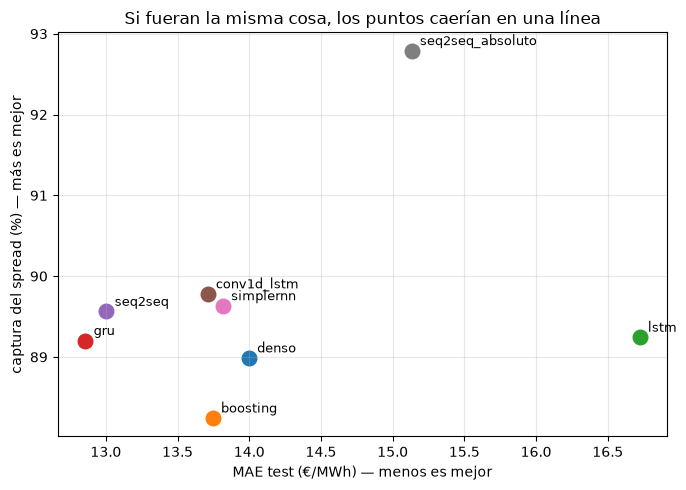

In [8]:
if not HAY:
    print("Sin resultados todavía.")
else:
    # res viene ordenada por MAE_val, asi que res.index[0] es el mejor en VALIDACION.
    # Llamarlo "mejor MAE" corona al que mejor se ajusto al periodo de seleccion, no al
    # que mejor predice 2025 -- justo el error que esta seccion quiere evitar.
    top_mae = res.MAE_test.idxmin()
    top_cap = res.captura_test.idxmax()
    print(f"mejor MAE     : {top_mae:20s} {res.loc[top_mae,'MAE_test']:.2f} €/MWh · "
          f"captura {res.loc[top_mae,'captura_test']:.1f}%")
    print(f"mejor captura : {top_cap:20s} {res.loc[top_cap,'MAE_test']:.2f} €/MWh · "
          f"captura {res.loc[top_cap,'captura_test']:.1f}%")
    print()
    if top_mae != top_cap:
        print("NO coinciden. Exportar los dos y decirlo en la memoria: es el Hallazgo 1")
        print("del informe de fases confirmado desde el lado del deep learning.")
    else:
        print("Coinciden en esta ejecución. Aun así conviene reportar las dos métricas:")
        print("la correlación entre ambas es -0,285, así que la coincidencia es suerte.")

    # Si la seccion 3 ya corrio, `tabla` trae ademas el ENSEMBLE y el naive. Dibujar
    # solo las familias dejaba fuera del grafico el mejor resultado del trabajo y el
    # liston contra el que se mide todo.
    G = tabla if "tabla" in globals() else res

    fig, ax = plt.subplots(figsize=(8.5, 6))
    nv_mae = G.loc["naive (persistencia)", "MAE_test"] if "naive (persistencia)" in G.index else None
    nv_cap = G.loc["naive (persistencia)", "captura_test"] if nv_mae is not None else None

    if nv_mae is not None:
        # las dos rectas parten el plano en cuadrantes: arriba-izquierda es "mejor que la
        # persistencia en las DOS metricas", que es lo unico que cuenta como ganar.
        ax.axvline(nv_mae, color="grey", ls="--", lw=1, zorder=0)
        ax.axhline(nv_cap, color="grey", ls="--", lw=1, zorder=0)
        ax.annotate("mejor en ambas", (0.03, 0.96), xycoords="axes fraction",
                    fontsize=9, color="grey", va="top")

    for nom, r in G.iterrows():
        if nom == "ENSEMBLE":
            ax.scatter(r.MAE_test, r.captura_test, s=420, marker="*",
                       color="crimson", zorder=5, edgecolor="black", linewidth=.6)
            peso = "bold"
        elif nom == "naive (persistencia)":
            ax.scatter(r.MAE_test, r.captura_test, s=150, marker="X",
                       color="grey", zorder=4)
            peso = "normal"
        else:
            ax.scatter(r.MAE_test, r.captura_test, s=110, color="steelblue", zorder=3)
            peso = "normal"
        ax.annotate(nom, (r.MAE_test, r.captura_test), xytext=(8, 5),
                    textcoords="offset points", fontsize=9, fontweight=peso)

    ax.set_xlabel("MAE test (€/MWh) — menos es mejor  ←")
    ax.set_ylabel("captura del spread (%) — más es mejor  ↑")
    ax.set_title("El campeón por error y el campeón por dinero no son el mismo")
    ax.grid(alpha=.3); plt.tight_layout()
    plt.savefig(SALIDA / "mae_vs_captura.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"grafico guardado en {SALIDA / 'mae_vs_captura.png'}")

## 5 · Qué queda guardado

Lo que hay en `data/gold/finales_<matriz>/` y para qué sirve cada cosa.

In [9]:
if not SALIDA.exists():
    print("Todavía no se ha ejecutado nada.")
else:
    for p in sorted(SALIDA.iterdir()):
        kb = p.stat().st_size / 1024
        que = {".keras": "el modelo",
               ".json": "preprocesado: escaladores y orden de columnas"}.get(p.suffix, "")
        if p.name == "meta.json":
            que = "matriz, hash y listones del naive"
        elif p.name == "por_semilla.csv":
            que = "una fila por entrenamiento"
        elif p.name.startswith("pred_val_"):
            que = "predicciones de validación, 365 días x 24 h"
        elif p.name.startswith("pred_test_"):
            que = "predicciones de test, 211 días x 24 h"
        elif p.name.endswith(".bak"):
            que = "copia previa al reentrenamiento de lstm/boosting/simplernn s0"
        print(f"  {kb:9,.0f} KB  {p.name:38s} {que}")
    print()
    print("Cada .keras necesita su .preprocesado.json para poder usarse. Al cargarlo hay")
    print("que comprobar que `hash_matriz` coincide con el de la matriz del día: si no,")
    print("fallar en voz alta -- un modelo con las columnas cambiadas de sitio sigue")
    print("prediciendo, y nadie se entera.")

          8 KB  boosting.preprocesado.json             preprocesado: escaladores y orden de columnas
          4 KB  boosting__s0                           
          4 KB  boosting__s1                           
          4 KB  boosting__s2                           
          8 KB  conv1d_lstm.preprocesado.json          preprocesado: escaladores y orden de columnas
      3,431 KB  conv1d_lstm__s0.keras                  el modelo
      3,431 KB  conv1d_lstm__s1.keras                  el modelo
      3,431 KB  conv1d_lstm__s2.keras                  el modelo
          8 KB  denso.preprocesado.json                preprocesado: escaladores y orden de columnas
      6,663 KB  denso__s0.keras                        el modelo
      6,663 KB  denso__s1.keras                        el modelo
      6,663 KB  denso__s2.keras                        el modelo
          8 KB  gru.preprocesado.json                  preprocesado: escaladores y orden de columnas
      2,365 KB  gru__s0.keras         